In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)  
print(y_train.shape)  
print(X_test.shape)   
print(y_test.shape)  


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [153]:
# normalize pixels value
X_train=X_train/255.0
X_test=X_test/255.0

# reinitialize shape
X_train=X_train.reshape(-1,28,28,1)  #just like reshape(60000,28,28,1) where 1 indicates channel
X_test=X_test.reshape(-1,28,28,1)
print(X_train.shape)

(60000, 28, 28, 1)


In [154]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [124]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model=Sequential()
# first conv layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

# second conv layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

# third conv layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,554 (236.54 KB)

 Trainable params: 60,554 (236.54 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
#Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=4, # how many epochs to wait before stopping
    restore_best_weights=True,
    verbose=1,
)


In [126]:
# compile model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [127]:
# train model
model_history=model.fit(X_train,y_train,epochs=9,batch_size=32,validation_split=0.2,callbacks=[early_stopping])


Epoch 1/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 31ms/step - accuracy: 0.9220 - loss: 0.2584 - val_accuracy: 0.9638 - val_loss: 0.1221
Epoch 2/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 30ms/step - accuracy: 0.9723 - loss: 0.0883 - val_accuracy: 0.9772 - val_loss: 0.0723
Epoch 3/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.9801 - loss: 0.0627 - val_accuracy: 0.9790 - val_loss: 0.0713
Epoch 4/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9844 - loss: 0.0498 - val_accuracy: 0.9831 - val_loss: 0.0522
Epoch 5/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 31ms/step - accuracy: 0.9866 - loss: 0.0409 - val_accuracy: 0.9833 - val_loss: 0.0559
Epoch 6/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9898 - loss: 0.0316 - val_accuracy: 0.9871 - val_loss: 0.0471
Epoch 7/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 30ms/step - accuracy: 0.9920 - loss: 0.0244 - val_accuracy: 0.9853 - val_loss: 0.0591
Restoring model weights from the end of the best epoch: 6.


In [128]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9860 - loss: 0.0517
Test Loss: 0.05167827010154724
Test Accuracy: 0.9860000014305115


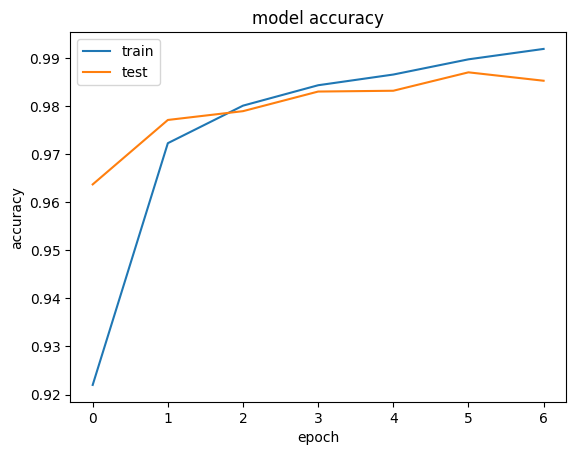

In [129]:
# summarize history from model
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='best')
plt.title('model accuracy')
plt.show()

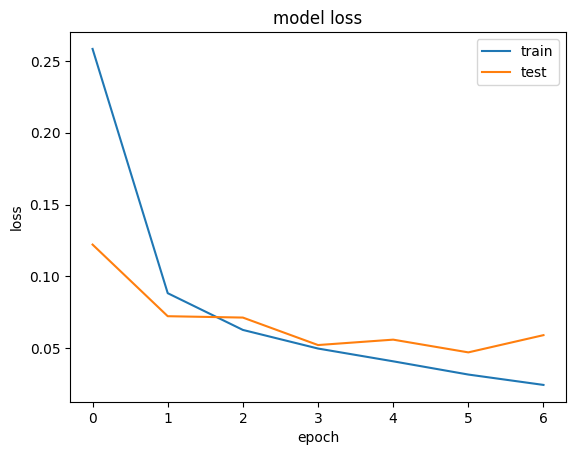

In [130]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('model loss')
plt.legend(['train','test'],loc='best')
plt.show()

In [158]:
y_pred = model.predict(X_test)
predicted_digit = np.argmax(y_pred, axis=1)

actual_digit = np.argmax(y_test[1])

print("Predicted:", predicted_digit[1])
print("Actual:", actual_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Predicted: 2
Actual: 2


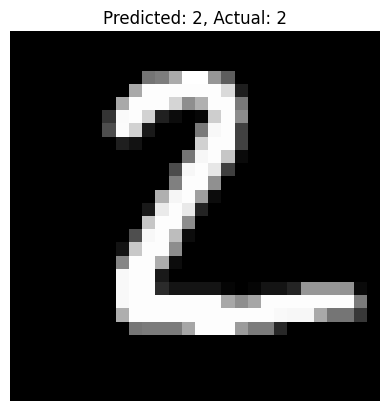

In [160]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(X_test[1].reshape(28, 28), cmap="gray")
plt.title(
    f"Predicted: {np.argmax(y_pred[1])}, Actual: {np.argmax(y_test[1])}"
)
plt.axis("off")
plt.show()

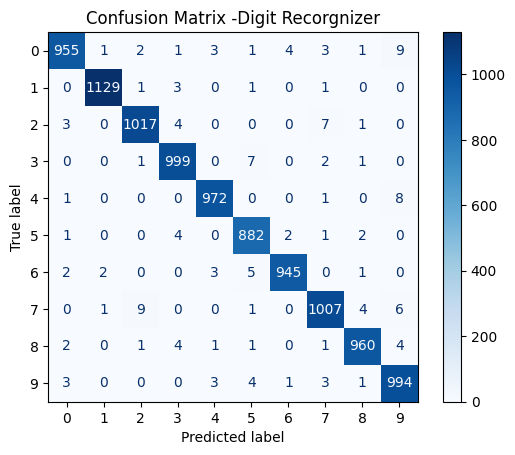

In [161]:
# from sklearn.metrics import ConfusionMatrixDisplay

# Convert y_test from one-hot encoding to single integer labels
y_test_labels = np.argmax(y_test, axis=1)

# Convert y_pred probabilities to single integer labels
y_pred_labels = np.argmax(y_pred, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels,
                                        cmap="Blues"
)
plt.title("Confusion Matrix -Digit Recorgnizer")
plt.show()